# Downscaling T2

In [1]:
import torch as pt
import xarray as xr
import pandas as pd
import numpy as np
import torch_dl4ds as dds
from torch_dl4ds import PostUpsamplingNet
from torch_dl4ds import Predictor


model_path = '/home/gvaillant1/downscaling/pretrained-models/T2/T2-Other-Models/t2_model.pth'

model = PostUpsamplingNet(
    backbone_block='resnet', 
    upsampling='spc',                  
    scale=3,               
    lr_size=(40, 40),           
    n_channels=6,                    
    n_filters=8,
    n_blocks=8,
    activation='relu',
    localcon_layer=True
)

model.load_state_dict(pt.load(model_path, map_location='cpu')) 
model.eval()



PostUpsamplingNet(
  (initial_conv): Conv2d(6, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (backbone): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (conv2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (conv1x1): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
    )
    (2): ResidualBlock(
      (conv1): Conv2d(16, 24, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (conv2): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (conv1x1): Conv2d(16, 24, kernel_size=(1, 1), stride=(1, 1))
    )
    (3): ResidualBlock(
      (conv1): Conv2d(24, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)

In [2]:
#Getting test data

uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

In [3]:
#FOR uWRF just make the latitude and longitude values only have y and x as the dimensions instead of time,y, x because at every time step it is the same

uwrf_train['latitude'] = uwrf_train['latitude'].isel(time=0)
uwrf_val['latitude'] = uwrf_val['latitude'].isel(time=0)
uwrf_test['latitude'] = uwrf_test['latitude'].isel(time=0)
#--
uwrf_train['longitude'] = uwrf_train['longitude'].isel(time=0)
uwrf_val['longitude'] = uwrf_val['longitude'].isel(time=0)
uwrf_test['longitude'] = uwrf_test['longitude'].isel(time=0)

In [4]:
uwrf_list = [uwrf_train, uwrf_val, uwrf_test]
nam_list = [nam_train, nam_val, nam_test]

for ds in uwrf_list: 
            
            # Calculate wind direction
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_direction = (np.arctan2(-u, -v) * 180 / np.pi + 360) % 360

            # Add wind speed as a new variable to the dataset
            ds['WD'] = (('time', 'y', 'x'), wind_direction)
            ds['WD'].attrs['units'] = 'degrees'
            ds['WD'].attrs['description'] = '10-meter wind direction (from which blowing)'


for ds in nam_list:

            # Calculate wind direction
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_direction = (np.arctan2(-u, -v) * 180 / np.pi + 360) % 360

            # Add wind speed as a new variable to the dataset
            ds['WD'] = (('time', 'y', 'x'), wind_direction)
            ds['WD'].attrs['units'] = 'degrees'
            ds['WD'].attrs['description'] = '10-meter wind direction (from which blowing)'

In [5]:
uwrf_list = [uwrf_train, uwrf_val, uwrf_test]
nam_list = [nam_train, nam_val, nam_test]

for ds in uwrf_list: 
            
            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'


for ds in nam_list:

            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'

In [14]:
var_list = ['T2']
pred_var_list = ['PSFC', 'U10', 'V10', 'SWDOWN', 'PBLH']

for var in var_list:
    # High resolution (uWRF) data
    var_hr_train = uwrf_train[var]
    var_hr_val = uwrf_val[var]
    var_hr_test = uwrf_test[var]

    # Combine predictor variables
    pred_var_hr_train = np.stack([uwrf_train[p] for p in pred_var_list], axis=1)
    pred_var_hr_val = np.stack([uwrf_val[p] for p in pred_var_list], axis=1)
    pred_var_hr_test = np.stack([uwrf_test[p] for p in pred_var_list], axis=1)

    # Low resolution (NAM) data
    var_lr_train = nam_train[var]
    var_lr_val = nam_val[var]
    var_lr_test = nam_test[var]
    
    #Combine LR predictor variables
    pred_var_lr_train = np.stack([nam_train[p] for p in pred_var_list], axis=1)
    pred_var_lr_val = np.stack([nam_val[p] for p in pred_var_list], axis=1)
    pred_var_lr_test = np.stack([nam_test[p] for p in pred_var_list], axis=1)

    # Normalize
    var_scaler_train = dds.TorchStandardScaler(axis=None)
    var_scaler_train.fit(var_hr_train)

    pred_var_scaler_train = dds.TorchStandardScaler(axis=None)
    pred_var_scaler_train.fit(pred_var_hr_train)

    # High resolution (targets)
    y_train = var_scaler_train.transform(var_hr_train)
    y_val = var_scaler_train.transform(var_hr_val)
    y_test = var_scaler_train.transform(var_hr_test)

    # Low resolution (inputs)
    x_train = var_scaler_train.transform(var_lr_train)
    x_val = var_scaler_train.transform(var_lr_val)
    x_test = var_scaler_train.transform(var_lr_test)

    y_train = np.expand_dims(y_train, axis=1)
    y_val = np.expand_dims(y_val, axis=1)
    y_test = np.expand_dims(y_test, axis=1)


    x_train = np.expand_dims(x_train, axis=1)
    x_val = np.expand_dims(x_val, axis=1)
    x_test = np.expand_dims(x_test, axis=1)

    # Create one scaler per predictor channel
    pred_var_scalers = []
    x_z_train_list, x_z_val_list, x_z_test_list = [], [], []
    y_z_train_list, y_z_val_list, y_z_test_list = [], [], []
    
    for i in range(pred_var_hr_train.shape[1]):
        scaler = dds.TorchStandardScaler(axis=None)
        scaler.fit(pred_var_hr_train[:, i])
        pred_var_scalers.append(scaler)
    
        y_z_train_list.append(np.expand_dims(scaler.transform(pred_var_hr_train[:, i]), axis=1))
        y_z_val_list.append(np.expand_dims(scaler.transform(pred_var_hr_val[:, i]), axis=1))
        y_z_test_list.append(np.expand_dims(scaler.transform(pred_var_hr_test[:, i]), axis=1))
    
        x_z_train_list.append(np.expand_dims(scaler.transform(pred_var_lr_train[:, i]), axis=1))
        x_z_val_list.append(np.expand_dims(scaler.transform(pred_var_lr_val[:, i]), axis=1))
        x_z_test_list.append(np.expand_dims(scaler.transform(pred_var_lr_test[:, i]), axis=1))
    
    # Concatenate all predictor channels along channel axis
    pred_var_train = np.concatenate(y_z_train_list, axis=1)
    pred_var_val = np.concatenate(y_z_val_list, axis=1)
    pred_var_test = np.concatenate(y_z_test_list, axis=1)

    pred_var_test = np.concatenate(x_z_test_list, axis=1)

In [15]:
# LR: (578, 1, 40, 40) 
test_array = x_test
test_predictors = pred_var_test

predictor = Predictor(
    trainer=model,
    array=test_array,
    scale=3,
    array_in_hr=False, 
    predictors=test_predictors,
    interpolation='inter_area',
    batch_size=32,
    scaler=None, 
    save_path=None, 
    save_fname='y_hat.npy',
    return_lr=False,
    device='cpu'
)


y_pred_normalized = predictor.run()
y_pred = var_scaler_train.inverse_transform(y_pred_normalized) #fix inverse transform now


In [16]:
import xarray as xr
import numpy as np
import torch
import pandas as pd


if isinstance(y_pred, torch.Tensor):
    y_pred = y_pred.cpu().numpy()


y_pred = np.squeeze(y_pred, axis=1)


times = uwrf_test['time'].values            # (2697,)
y_coords = uwrf_test['y'].values            # (120,)
x_coords = uwrf_test['x'].values            # (120,)
lat2d = uwrf_test['latitude'].values        # (120, 120)
lon2d = uwrf_test['longitude'].values       # (120, 120)

# Create DataArray matching uWRF format
T2_da = xr.DataArray(
    data=y_pred,
    dims=("time", "y", "x"),
    coords={
        "time": times,
        "y": y_coords,
        "x": x_coords,
        "latitude": (("y", "x"), lat2d),
        "longitude": (("y", "x"), lon2d),
    },
    name="T2"
)



In [17]:
y_true_normalized = y_test
# Inverse-transform:
y_true_real = var_scaler_train.inverse_transform(y_true_normalized)

# Compute MAE in K
mae = np.mean(np.abs(y_pred - y_true_real))

In [18]:
mae

np.float32(4.8835287)

In [19]:
y_true_real.shape

(578, 1, 120, 120)

In [20]:
y_pred.shape

(578, 120, 120)

In [21]:
# Compute absolute error
abs_error = np.abs(y_true_real - y_pred)

# Compute MAE across ALL elements
mae = np.mean(abs_error)

print(f"Overall MAE: {mae:.4f}")

Overall MAE: 4.8835


In [22]:
print(f"y_pred shape: {y_pred.shape}")
print(f"y_true shape: {y_true_real.shape}")

y_pred shape: (578, 120, 120)
y_true shape: (578, 1, 120, 120)


In [23]:
y_true_real = y_true_real.squeeze(1)
y_true_real.shape

(578, 120, 120)

In [24]:
import numpy as np
mae_normalized = np.mean(np.abs(y_pred_normalized - y_test))

In [25]:
mae_normalized

np.float32(0.23579942)

In [26]:
mae

np.float32(4.8835287)

# Visualize results

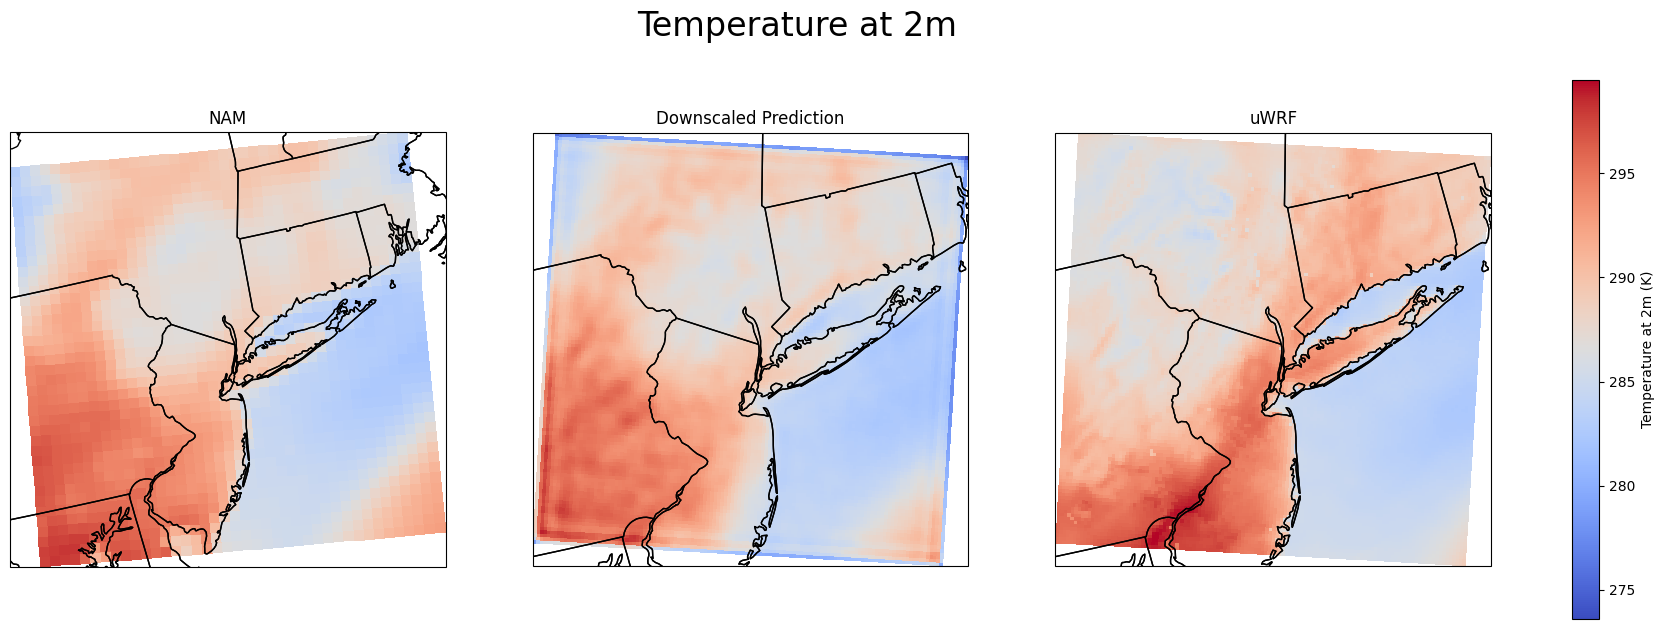

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import cartopy.feature as cfeature


# Extract data
nam = nam_test.T2  # input
results= T2_da #output
uwrf = uwrf_test.T2  # target


time_idx = 0 # CHANGE

lat_nam = nam.latitude[:,:].values
lon_nam = nam.longitude[:,:].values
t2_nam = nam[time_idx,:,:].values

lat_uwrf = uwrf.latitude[:,:].values
lon_uwrf = uwrf.longitude[:,:].values
t2_uwrf = uwrf[time_idx,:,:].values

# Prediction values — want to be the same resolution as uWRF
t2_pred = results[time_idx, :, :]

# common color limits
vmin = min(t2_nam.min(), t2_pred.min(), t2_uwrf.min())
vmax = max(t2_nam.max(), t2_pred.max(), t2_uwrf.max())


fig, axes = plt.subplots(1, 3, figsize=(21, 7), subplot_kw={'projection': ccrs.LambertConformal()})

# Plot NAM
im0 = axes[0].pcolormesh(lon_nam, lat_nam, t2_nam, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[0].set_title(f'NAM')
axes[0].coastlines()
#axes[0].gridlines(draw_labels=True)
axes[0].add_feature(cfeature.STATES)

# Plot Prediction
im1 = axes[1].pcolormesh(lon_uwrf, lat_uwrf, t2_pred, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[1].set_title(f'Downscaled Prediction')
axes[1].coastlines()
#axes[1].gridlines(draw_labels=True)
axes[1].add_feature(cfeature.STATES)

# Plot uWRF
im2 = axes[2].pcolormesh(lon_uwrf, lat_uwrf, t2_uwrf, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[2].set_title(f'uWRF')
axes[2].coastlines()
#axes[2].gridlines(draw_labels=True)
axes[2].add_feature(cfeature.STATES)

# Single shared colorbar
cbar = fig.colorbar(im2, ax=axes, orientation='vertical', fraction=0.04, pad=0.05)
cbar.set_label('Temperature at 2m (K)')

# Add main title
fig.suptitle(f'Temperature at 2m', fontsize=24)


plt.show()